# 프로젝트 1
## < MSE 손실함수 값 3000 이하를 달성하기 >

##### 첫 번째 프로젝트에서는 우리가 오늘 많은 시간을 들여서 직접 실습해 보았던 모델 설계, 손실함수 정의와 기울기 계산을 구현해 보겠습니다.
##### 새로운 데이터로 프로젝트를 진행하지만, 과정은 모두 동일합니다. 함께 진행했던 과정과 코드를 참고하여 충분히 고민한 후 진행해 보세요.
##### 데이터는 sklearn.datasets에 있는 데이터 중 하나인 당뇨병 데이터를 사용하겠습니다.

학습 노트 (시작 전 정리)

1. 지도학습 / 회귀
- 지도학습은 문제(입력 X)랑 정답(y)을 같이 주고 관계를 배우는거임
- y가 숫자면 회귀, y가 분류(개/고양이 같은거)면 분류
- 이번건 당뇨병 진행도(숫자) 맞히는거라서 회귀 (회귀 지도학습)

2. 당뇨병 데이터
- X : 환자 1명당 건강지표 10개 (나이, 성별, BMI, 혈압 등)
- y : 1년뒤 당뇨병 진행 정도 숫자
- 목표 : 건강지표 10개 보고 진행도 예측하기

3. 이 프로젝트 큰그림
- 프로젝트1 은 선형회귀를 라이브러리 없이 직접 만들어봄 (모델, 손실함수, 기울기, 경사하강법)
- 프로젝트2 는 같은걸 sklearn 으로 그냥 갖다씀

In [10]:
# (0) 한글 폰트 설정 - 그래프 제목 한글 깨짐/경고 방지
# 맨 위에서 한 번만 실행하면 이후 모든 그래프에 적용됨

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 ttf 를 matplotlib 에 등록 (리눅스 환경 기준 경로)
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스(-) 기호 깨짐 방지

In [11]:
# (1) 데이터 가져오기

from sklearn.datasets import load_diabetes

# load_diabetes 로 당뇨병 연습용 데이터 묶음을 불러옴
# data 안에 입력이랑 정답이 다 들어있음
data = load_diabetes()

df_X = data.data    # 입력 X (건강지표 10개)
df_y = data.target  # 정답 y (당뇨병 진행도 숫자)

In [21]:
# (2) 모델에 입력할 데이터 X 준비하기

import numpy as np  # 숫자 계산 빠르게 해주는 라이브러리

# df_X 를 numpy 배열로 바꿔서 X 에 담음
# 배열로 바꿔야 행렬계산이 편하고 빠름
X = np.array(df_X)

# type 은 변수가 뭔지, dtype 은 안에 든 숫자가 뭔지
print(type(X), X.dtype)

'''
표로 된 데이터는 행렬과 같다고 볼 수 있다.
행렬(배열) 계산을 쉽고 빠르게 하려고 numpy 배열로 바꾼다.
(대표적으로 예측을 행렬곱 한 줄로 계산할 수 있다.)
'''


<class 'numpy.ndarray'> float64


'\n표로 된 데이터는 행렬과 같다고 볼 수 있다.\n행렬(배열) 계산을 쉽고 빠르게 하려고 numpy 배열로 바꾼다.\n(대표적으로 예측을 행렬곱 한 줄로 계산할 수 있다.)\n'

In [22]:
# (3) 모델에 예측할 데이터 Y준비하기

# 위 (2)번이랑 똑같은데 정답 y 로 한거임
y = np.array(df_y)  # 정답도 numpy 배열로

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [23]:
# (4) train 데이터와 test 데이터로 분리하기

# 학습에 쓴 데이터로 시험보면 답 외운건지 모름
# 그래서 훈련용(train) 따로, 시험용(test) 따로 나눔 : train_test_split가 그 역할.
from sklearn.model_selection import train_test_split

# test_size=0.2 는 20% 를 시험용으로
# random_state=42 는 섞는걸 항상 똑같게 고정 (재현용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# shape 는 (행, 열) = (샘플수, 특성수)
print(X_train.shape, y_train.shape)  # 훈련 353명
print(X_test.shape, y_test.shape)    # 시험 89명

'''
random_state 정리

- random_state 는 랜덤의 "씨앗(seed)" 값임. 42 라는 숫자 자체는 특별한 의미 없음.
- 같은 씨앗 넣으면 항상 같은 순서로 섞임. 다른 숫자(0, 7, 100)도 다 똑같이 작동함.
- 씨앗을 아예 안 넣으면 돌릴때마다 다르게 섞여서 점수도 매번 바뀜.
- 그래서 고정해두면 항상 같은 조건에서 비교 가능 (재현성). 남이 돌려도 같은 결과 나옴.
- 42 가 많은 이유는 그냥 개발자들 관습/농담이라고 함. (히치하이커 안내서). 7 로 바꿔도 됨.

  예) random_state=100 으로 바꾸면 -> 에러 안나고, 일관되긴 한데 42 일때와는 다른 분리가 됨.
'''

(353, 10) (353,)
(89, 10) (89,)


'\nrandom_state 정리\n\n- random_state 는 랜덤의 "씨앗(seed)" 값임. 42 라는 숫자 자체는 특별한 의미 없음.\n- 같은 씨앗 넣으면 항상 같은 순서로 섞임. 다른 숫자(0, 7, 100)도 다 똑같이 작동함.\n- 씨앗을 아예 안 넣으면 돌릴때마다 다르게 섞여서 점수도 매번 바뀜.\n- 그래서 고정해두면 항상 같은 조건에서 비교 가능 (재현성). 남이 돌려도 같은 결과 나옴.\n- 42 가 많은 이유는 그냥 개발자들 관습/농담이라고 함. (히치하이커 안내서). 7 로 바꿔도 됨.\n\n  예) random_state=100 으로 바꾸면 -> 에러 안나고, 일관되긴 한데 42 일때와는 다른 분리가 됨.\n'

In [24]:
# (5) 모델 준비하기

# 선형회귀 = 예측값을 w1*x1 + w2*x2 + ... + b 이렇게 계산하는거
# W 는 가중치(특성마다 하나씩, 총 10개), b 는 편향(절편) 1개
# 학습이란건 결국 정답 잘맞추는 W, b 를 찾는 과정임

W = np.random.rand(X_train.shape[1])  # W 초기값 (랜덤으로 10개 시작). X의 shape(353, 10) 에서 1번 인덱스 10을 가져옴. 
b = np.random.rand()                  # b 초기값 (랜덤 1개)

print(len(W))

# model : X 랑 W, b 로 예측값 계산하는 함수
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]  # i번째 특성 곱하기 i번째 가중치
    predictions += b                   # 마지막에 b 더함
    return predictions

'''
가중치(W) 초기값 정리
- 여기 W, b 는 사람이 경험으로 정한 값이 아님. np.random.rand 로 컴퓨터가 랜덤하게 뽑은 "시작값"임.
- 사람이 정한건 "랜덤으로 시작하자" 라는 방법뿐이고, 실제 숫자는 무작위임.
- 그리고 이 랜덤 초기값은 학습 시작하면 곧바로 다른 값으로 바뀜 (출발점일 뿐).
- 진짜 W, b 는 (9)번 학습에서 1000번 반복하며 자동으로 찾아짐.
- 비유: 깜깜한 산에 아무데나 떨어뜨려놓고(랜덤 시작) 가장 낮은 골짜기(손실 최소)로 내려가게 함.

편향(b, bias) 정리
- 편향 = 입력과 상관없이 항상 더해지는 고정값. 그래프에선 x=0 일때의 y값(y절편).
- 편향이 없으면 (y = w*x) 선이 무조건 원점(0,0)을 지나야해서 너무 빡빡함.
  예) 점수 = w*공부시간 이면 0시간 = 무조건 0점 이 됨.
- 편향이 있으면 (y = w*x + b) 0시간이어도 기본 30점 같은걸 표현 가능. 선이 위아래로 자유롭게 움직임.
- 저울 비유: 빈 저울인데 2kg 가리키면, 그 +2 가 편향. 입력과 무관하게 늘 더해지는 값이라 "치우침(편향)".

총 정리
- W : 입력이 1 늘때 결과가 얼마나 변하나 (기울기). 학습으로 찾음.
- b : 입력과 무관하게 늘 더해지는 기본값 (y절편). 선을 위아래로 옮김.
'''

10


'\n가중치(W) 초기값 정리\n- 여기 W, b 는 사람이 경험으로 정한 값이 아님. np.random.rand 로 컴퓨터가 랜덤하게 뽑은 "시작값"임.\n- 사람이 정한건 "랜덤으로 시작하자" 라는 방법뿐이고, 실제 숫자는 무작위임.\n- 그리고 이 랜덤 초기값은 학습 시작하면 곧바로 다른 값으로 바뀜 (출발점일 뿐).\n- 진짜 W, b 는 (9)번 학습에서 1000번 반복하며 자동으로 찾아짐.\n- 비유: 깜깜한 산에 아무데나 떨어뜨려놓고(랜덤 시작) 가장 낮은 골짜기(손실 최소)로 내려가게 함.\n\n편향(b, bias) 정리\n- 편향 = 입력과 상관없이 항상 더해지는 고정값. 그래프에선 x=0 일때의 y값(y절편).\n- 편향이 없으면 (y = w*x) 선이 무조건 원점(0,0)을 지나야해서 너무 빡빡함.\n  예) 점수 = w*공부시간 이면 0시간 = 무조건 0점 이 됨.\n- 편향이 있으면 (y = w*x + b) 0시간이어도 기본 30점 같은걸 표현 가능. 선이 위아래로 자유롭게 움직임.\n- 저울 비유: 빈 저울인데 2kg 가리키면, 그 +2 가 편향. 입력과 무관하게 늘 더해지는 값이라 "치우침(편향)".\n\n총 정리\n- W : 입력이 1 늘때 결과가 얼마나 변하나 (기울기). 학습으로 찾음.\n- b : 입력과 무관하게 늘 더해지는 기본값 (y절편). 선을 위아래로 옮김.\n'

In [25]:
# (6) 손실함수 loss 정의하기

# 손실함수 = 예측이 정답이랑 얼마나 틀렸나를 숫자 하나로 나타낸거
# 작을수록 좋은 모델. 학습 목표가 이 값 줄이는거임

# MSE = (예측 - 정답) 제곱해서 평균낸거
# 제곱하는 이유는 부호 없애고 큰 오차에 벌점 더 주려고
def MSE(a, b):
    mse = ((a - b) ** 2).mean()
    return mse

# loss : 예측 만들고 MSE 로 손실 계산 (9)에서 참조.
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [26]:
# (7) 기울기를 구하는 gradient 함수 구현하기

# 기울기 = 손실 줄이려면 W, b 를 어느쪽으로 바꿔야 하는지 알려주는거
# 미분으로 구함. 기울기 반대방향으로 가면 손실이 줄어듬 (경사하강법)
def gradient(X, W, b, y):
    N = len(y)  # 샘플 개수

    y_pred = model(X, W, b)  # 지금 예측값

    # dW : W 에 대한 기울기. MSE 미분하면 이렇게 나옴
    dW = 1/N * 2 * X.T.dot(y_pred - y)  # X.T 는 전치, dot 은 행렬곱

    # db : b 에 대한 기울기
    db = 2 * (y_pred - y).mean()
    return dW, db

'''
전치(X.T) 를 왜 하는지 정리

핵심 : 계산이 "특성별로" 더해지게 하려고 뒤집는거임.
- 구하려는 dW 는 "특성 10개 각각의 기울기" 임.
  즉 특성1은 오차에 얼마나 기여했나, 특성2는... 을 특성마다 하나씩.
- 데이터 모양 : X (353명 x 특성10), 오차(353명), 우리가 원하는 dW(특성10)

작은 예 (환자2명, 특성2개)
  X = [[2, 3],     <- 환자1 (특성1=2, 특성2=3)
       [4, 5]]     <- 환자2 (특성1=4, 특성2=5)
  오차 = [e1, e2]

  원하는 값:
    dw1 = 2*e1 + 4*e2   (특성1 값들 x 오차들 더하기)
    dw2 = 3*e1 + 5*e2   (특성2 값들 x 오차들 더하기)

  그냥 X 로 곱하면 (전치 안함) -> 틀림
    X · 오차 = [2*e1+3*e2, 4*e1+5*e2]  <- 한 환자 안에서 특성을 섞어버림 (환자별 결과, 우리가 원한게 아님)

  X.T (전치) 로 곱하면 -> 맞음
    X.T = [[2, 4],   <- 특성1 값들 (모든 환자)
           [3, 5]]   <- 특성2 값들 (모든 환자)
    X.T · 오차 = [2*e1+4*e2, 3*e1+5*e2] = [dw1, dw2]  <- 우리가 원하던 그거!

전치의 효과
- 데이터를 "환자별 정렬" -> "특성별 정렬" 로 돌려놔서
  각 가중치가 모든 샘플 오차랑 제대로 짝지어 더해지게 만듦.
- 덤으로 행렬곱 모양도 맞음 :
    X.T(10x353) · 오차(353) -> dW(10)  OK
    X (353x10) · 오차(353) -> 모양 안맞아서 에러
- "모양 맞추려고 뒤집는다" = "특성별로 더하려고 뒤집는다".
'''

'\n전치(X.T) 를 왜 하는지 정리\n\n핵심 : 계산이 "특성별로" 더해지게 하려고 뒤집는거임.\n- 구하려는 dW 는 "특성 10개 각각의 기울기" 임.\n  즉 특성1은 오차에 얼마나 기여했나, 특성2는... 을 특성마다 하나씩.\n- 데이터 모양 : X (353명 x 특성10), 오차(353명), 우리가 원하는 dW(특성10)\n\n작은 예 (환자2명, 특성2개)\n  X = [[2, 3],     <- 환자1 (특성1=2, 특성2=3)\n       [4, 5]]     <- 환자2 (특성1=4, 특성2=5)\n  오차 = [e1, e2]\n\n  원하는 값:\n    dw1 = 2*e1 + 4*e2   (특성1 값들 x 오차들 더하기)\n    dw2 = 3*e1 + 5*e2   (특성2 값들 x 오차들 더하기)\n\n  그냥 X 로 곱하면 (전치 안함) -> 틀림\n    X · 오차 = [2*e1+3*e2, 4*e1+5*e2]  <- 한 환자 안에서 특성을 섞어버림 (환자별 결과, 우리가 원한게 아님)\n\n  X.T (전치) 로 곱하면 -> 맞음\n    X.T = [[2, 4],   <- 특성1 값들 (모든 환자)\n           [3, 5]]   <- 특성2 값들 (모든 환자)\n    X.T · 오차 = [2*e1+4*e2, 3*e1+5*e2] = [dw1, dw2]  <- 우리가 원하던 그거!\n\n전치의 효과\n- 데이터를 "환자별 정렬" -> "특성별 정렬" 로 돌려놔서\n  각 가중치가 모든 샘플 오차랑 제대로 짝지어 더해지게 만듦.\n- 덤으로 행렬곱 모양도 맞음 :\n    X.T(10x353) · 오차(353) -> dW(10)  OK\n    X (353x10) · 오차(353) -> 모양 안맞아서 에러\n- "모양 맞추려고 뒤집는다" = "특성별로 더하려고 뒤집는다".\n'

In [27]:
# (8) 하이퍼 파라미터인 학습률 설정하기

# 학습률 = 기울기 방향으로 한걸음 얼마나 크게 갈지 정하는 값
# 너무 작으면 느리게감 (이 코드가 그래서 1000번 돌려도 목표 미달)
# 너무 크면 너무 뛰어서 발산함
# 하이퍼파라미터 = 사람이 직접 정해주는 값
#LEARNING_RATE = 0.001
LEARNING_RATE = 0.1

'''
하이퍼파라미터 vs 임계치(threshold) 정리

둘 다 사람이 정하는 숫자라 헷갈리는데 역할이 완전 다름.

- 하이퍼파라미터 = 모델이 "어떻게 학습할지" 정하는 설정값
  . 학습 시작 "전"에 사람이 정함
  . 예) 학습률 0.001, 반복 1000번, 트리 깊이 등
  . 모델이 학습으로 찾는 W, b 랑은 구분됨 (데이터로 배우는게 아니라 손으로 세팅)
  . 이 셀의 LEARNING_RATE 가 딱 하이퍼파라미터.

- 임계치(threshold) = 결과를 보고 "어떻게 판단할지" 정하는 기준선
  . 학습 "후" 예측결과를 자를때 씀. 주로 분류에서 나옴.
  . 예) 스팸확률 0.8 인데, 임계치 0.5 넘으면 "스팸" 으로 판정
  . 0.5 -> 0.9 로 올리면 확실할때만 스팸처리 (판단이 빡빡해짐)

비유 (시험공부)
- 하이퍼파라미터 = 하루 몇시간, 며칠 공부할지 (공부 "방식")
- 임계치 = 몇점부터 합격으로 칠지 (결과 "합/불 가르는 선")

참고 : 회귀(숫자예측) 모델에서는 임계치 안나옴.
      임계치는 "이거냐 저거냐" 가르는 분류에서 주로 등장.
'''

'\n하이퍼파라미터 vs 임계치(threshold) 정리\n\n둘 다 사람이 정하는 숫자라 헷갈리는데 역할이 완전 다름.\n\n- 하이퍼파라미터 = 모델이 "어떻게 학습할지" 정하는 설정값\n  . 학습 시작 "전"에 사람이 정함\n  . 예) 학습률 0.001, 반복 1000번, 트리 깊이 등\n  . 모델이 학습으로 찾는 W, b 랑은 구분됨 (데이터로 배우는게 아니라 손으로 세팅)\n  . 이 셀의 LEARNING_RATE 가 딱 하이퍼파라미터.\n\n- 임계치(threshold) = 결과를 보고 "어떻게 판단할지" 정하는 기준선\n  . 학습 "후" 예측결과를 자를때 씀. 주로 분류에서 나옴.\n  . 예) 스팸확률 0.8 인데, 임계치 0.5 넘으면 "스팸" 으로 판정\n  . 0.5 -> 0.9 로 올리면 확실할때만 스팸처리 (판단이 빡빡해짐)\n\n비유 (시험공부)\n- 하이퍼파라미터 = 하루 몇시간, 며칠 공부할지 (공부 "방식")\n- 임계치 = 몇점부터 합격으로 칠지 (결과 "합/불 가르는 선")\n\n참고 : 회귀(숫자예측) 모델에서는 임계치 안나옴.\n      임계치는 "이거냐 저거냐" 가르는 분류에서 주로 등장.\n'

In [28]:
%%timeit -n 1 -r 1

# (9) 모델 학습하기

# 기울기 구하고 W, b 갱신하는걸 1000번 반복함
# %%timeit 은 실행시간 재는 명령 (학습이랑은 상관없음)
global W, b  # 함수 밖 W, b 를 여기서 바꾸겠다는 뜻

losses = []  # 손실값 기록용 (나중에 그래프)

for i in range(1, 10001):  # 1000번 반복
    dW, db = gradient(X_train, W, b, y_train)  # 기울기 구함
    W -= LEARNING_RATE * dW  # W 갱신 (기울기 반대방향)
    b -= LEARNING_RATE * db  # b 갱신
    L = loss(X_train, W, b, y_train)  # 갱신후 손실 계산
    losses.append(L)
    if i % 100 == 0:  # 100번마다 출력
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 5379.4647
Iteration 200 : Loss 4877.0985
Iteration 300 : Loss 4503.5578
Iteration 400 : Loss 4222.1145
Iteration 500 : Loss 4006.9307
Iteration 600 : Loss 3839.7849
Iteration 700 : Loss 3707.7877
Iteration 800 : Loss 3601.7862
Iteration 900 : Loss 3515.2499
Iteration 1000 : Loss 3443.4919
Iteration 1100 : Loss 3383.1244
Iteration 1200 : Loss 3331.6781
Iteration 1300 : Loss 3287.3342
Iteration 1400 : Loss 3248.7382
Iteration 1500 : Loss 3214.8677
Iteration 1600 : Loss 3184.9395
Iteration 1700 : Loss 3158.3449
Iteration 1800 : Loss 3134.6026
Iteration 1900 : Loss 3113.3262
Iteration 2000 : Loss 3094.2002
Iteration 2100 : Loss 3076.9636
Iteration 2200 : Loss 3061.3971
Iteration 2300 : Loss 3047.3141
Iteration 2400 : Loss 3034.5547
Iteration 2500 : Loss 3022.9797
Iteration 2600 : Loss 3012.4679
Iteration 2700 : Loss 3002.9123
Iteration 2800 : Loss 2994.2185
Iteration 2900 : Loss 2986.3025
Iteration 3000 : Loss 2979.0895
Iteration 3100 : Loss 2972.5125
Iteration 3200 : 

In [29]:
# (10) test 데이터에 대한 성능 확인하기

# 학습에 안쓴 시험데이터로 예측해서 진짜 성능 봄
prediction = model(X_test, W, b)  # 시험데이터 예측
mse = loss(X_test, W, b, y_test)  # 시험데이터 손실
mse  # 약 5168 나옴. 목표 3000 보다 큼 (학습 부족)

'''
목표(MSE 3000 이하) 달성 기록

- 처음엔 학습률 0.001 + 반복 1000번 이라서 test MSE 5168 -> 목표 미달이었음.
- 원인 : 당뇨병 데이터는 X값이 아주 작아서(0.05 같은 소수) 가중치가 큰값까지 가야하는데
         보폭(학습률)이 너무 작아 1000번으론 바닥까지 못 내려감 (학습 부족).

- 바꾼거
  . 학습률 0.001 -> 0.1   (보폭 100배 키움)
  . 반복 1000 -> 10000    (걸음수 10배 늘림)

- 결과 : test MSE 약 2881 -> 목표 3000 이하 달성!
- 참고 : 이 데이터 선형회귀의 이론적 최저 MSE 가 대략 2900 근처라 거의 최선까지 학습된 것으로 보임.
'''

'\n목표(MSE 3000 이하) 달성 기록\n\n- 처음엔 학습률 0.001 + 반복 1000번 이라서 test MSE 5168 -> 목표 미달이었음.\n- 원인 : 당뇨병 데이터는 X값이 아주 작아서(0.05 같은 소수) 가중치가 큰값까지 가야하는데\n         보폭(학습률)이 너무 작아 1000번으론 바닥까지 못 내려감 (학습 부족).\n\n- 바꾼거\n  . 학습률 0.001 -> 0.1   (보폭 100배 키움)\n  . 반복 1000 -> 10000    (걸음수 10배 늘림)\n\n- 결과 : test MSE 약 2881 -> 목표 3000 이하 달성!\n- 참고 : 이 데이터 선형회귀의 이론적 최저 MSE 가 대략 2900 근처라 거의 최선까지 학습된 것으로 보임.\n'

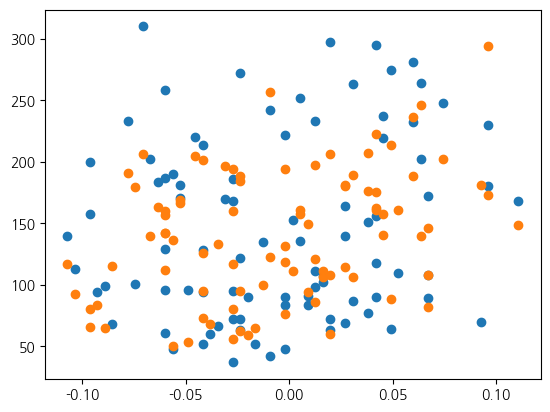

In [30]:
# (11) 정답 데이터와 예측한 데이터 시각화하기

import matplotlib.pyplot as plt  # 그래프 그리는거

# x축은 첫번째 특성, 파랑은 정답 주황은 예측
plt.scatter(X_test[:, 0], y_test)      # 실제 정답
plt.scatter(X_test[:, 0], prediction)  # 모델 예측
plt.show()
# 파랑이랑 주황이 잘 안겹침 = 아직 예측이 별로라는 뜻

# 프로젝트 2
## RMSE 값 150 이하를 달성

##### 마지막 프로젝트로는 보다 실용적인 데이터셋을 활용할 예정입니다. 바로 그 유명한 캐글(Kaggle) 경진대회에서 제공하는 데이터셋인데요!
##### 데이터셋의 주제는 시간, 온도, 습도, 계절 등의 정보가 담긴 데이터를 통해 자전거의 대여량을 예측하는 문제입니다.
##### 자전거 대여량을 결정하는 데에는 시간도 중요할 것이고, 요일이나 계절도 크게 영향을 미칠 것 같습니다.
##### 이번 프로젝트에서는 직접 손실함수와 기울기를 계산하지 않고, 사이킷런(sklearn)의 LinearRegression 모델을 활용할 것입니다.

In [31]:
# (1) 데이터 가져오기

import pandas as pd  # 표 형태 데이터 다루는거 (엑셀같은거)

# csv 파일 읽어서 표로 만듬 (경로는 상대경로로 고침)
train = pd.read_csv("bike-sharing-demand/train.csv")

# info 는 표 정보 보여줌 (행개수, 컬럼, 자료형 등)
train.info()
# 10886행 12컬럼. count 가 정답(자전거 대여량)
# casual + registered = count 라서 입력에 쓰면 반칙됨 (그래서 나중에 뺌. 예측 시점에 모를 정보를 입력에 넣으면 컨닝임.(train/test 데이터 분리할때 뺌))

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [32]:
# (2) datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기

# 날짜가 문자열이라 모델이 못씀. 연/월/일/시 숫자로 쪼개야 시간대별 패턴 학습 가능
train['datetime'] = pd.to_datetime(train['datetime'])  # 문자열을 날짜형으로

train['year'] = train['datetime'].dt.year      # 연도만 뽑기
train['month'] = train['datetime'].dt.month    # 월
train['day'] = train['datetime'].dt.day        # 일
train['hour'] = train['datetime'].dt.hour      # 시 (대여량에 제일 중요할듯)
train['minute'] = train['datetime'].dt.minute  # 분 (근데 다 0임. 쓸모없음)
train['second'] = train['datetime'].dt.second  # 초 (이것도 다 0)

train.info()  # 컬럼 12 -> 18 개로 늘어남

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-null  int32

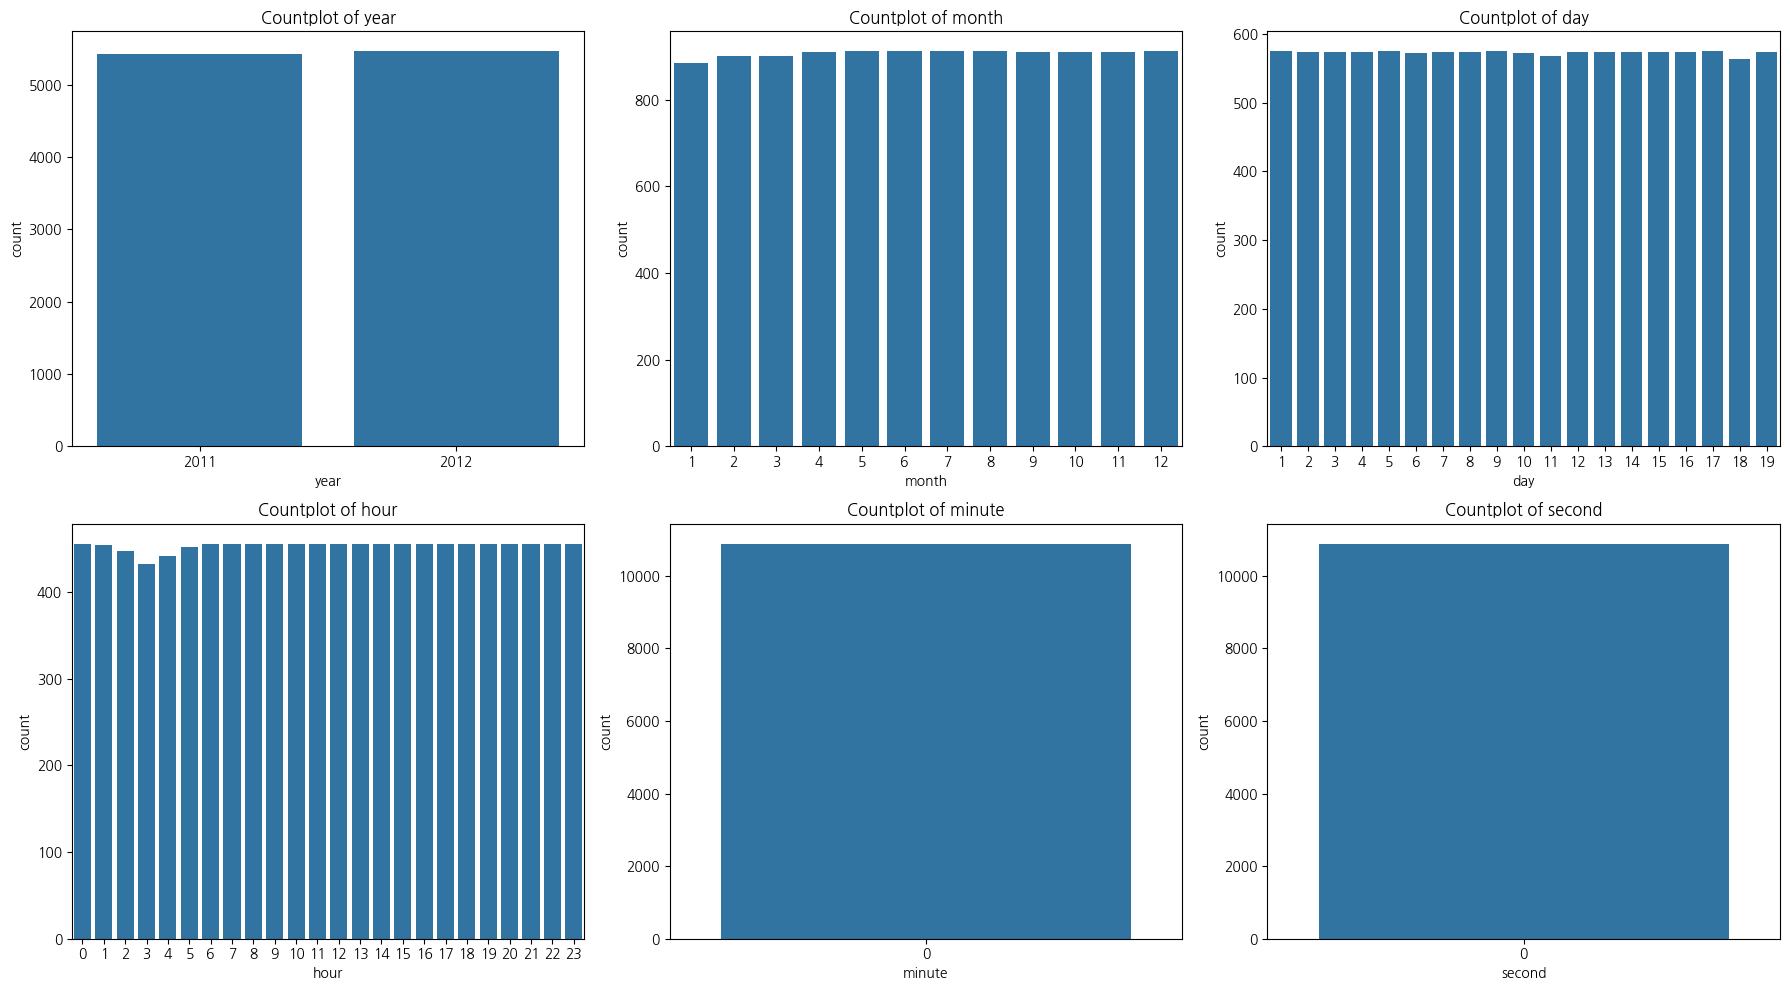

In [33]:
# (3) year, month, day, hour, minute, second 데이터 개수 시각화하기

import matplotlib.pyplot as plt
import seaborn as sns  # matplotlib 위에서 동작하는 도구. 통계 그래프를 한 줄로 예쁘게 그려줌

# 2행 3열 = 그래프 6개 한판에 그림
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):  # 6칸이랑 6컬럼 짝지어서 반복
    sns.countplot(x=col, data=train, ax=ax)  # countplot 은 값마다 개수 막대그래프
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()  # 그래프 간격 정리
plt.show()
# minute, second 는 막대가 0 에 하나뿐임 = 정보없음 확인

In [34]:
# (4) X, y 컬럼 선택 및 train/test 데이터 분리

# 입력 컬럼 고르기
# - 범주형(순서/크기 의미 없는거)은 원핫 대상 : hour, season, weather, month, year
# - 숫자 크기가 의미있는건 그대로   : temp, humidity, windspeed, atemp
# - holiday, workingday 는 이미 0/1 이라 그냥 둠
# - day(일자)는 예측에 의미없는 노이즈라 뺌
features = ['year', 'month', 'hour', 'temp', 'humidity', 'windspeed',
            'season', 'holiday', 'workingday', 'weather', 'atemp']    # count는 정답이므로 여기서 뺌.
X = train[features]
y = train['count']   # 정답 y (대여량)

# 원핫인코딩 : 범주형 컬럼을 0/1 칸 여러개로 쪼갬 (값마다 독립 가중치 갖게)
# 예) hour -> hour_0, hour_1, ... hour_23 (해당 시간만 1, 나머지 0)
X = pd.get_dummies(X, columns=['hour', 'season', 'weather', 'month', 'year'])

from sklearn.model_selection import train_test_split
# 프로젝트1 이랑 똑같이 80% 훈련 20% 시험으로 나눔, random_state=42도 동일하게.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

'''
원핫인코딩(one-hot) 정리

- 문제 : 선형회귀는 hour 를 숫자로 넣으면 "직선 관계"로만 봄.
        근데 대여량은 출근8시/퇴근18시 봉우리 2개짜리 꼬불꼬불 곡선 -> 직선으로 못맞춤.
- 해결 : hour 를 hour_0 ~ hour_23 처럼 0/1 칸 24개로 쪼갬 (원핫).
        그러면 시간마다 독립 가중치를 가져서 "8시 +200, 새벽 +5" 식으로 따로 학습 가능.
- 그래서 순서/크기 의미없는 범주형(hour, season, weather, month, year)은 원핫이 효과 큼.
- 반대로 temp, humidity 는 숫자 크기가 의미있어서(높을수록~) 그냥 둠.

결과 : RMSE 141 -> 약 100 으로 떨어짐.
'''

'\n원핫인코딩(one-hot) 정리\n\n- 문제 : 선형회귀는 hour 를 숫자로 넣으면 "직선 관계"로만 봄.\n        근데 대여량은 출근8시/퇴근18시 봉우리 2개짜리 꼬불꼬불 곡선 -> 직선으로 못맞춤.\n- 해결 : hour 를 hour_0 ~ hour_23 처럼 0/1 칸 24개로 쪼갬 (원핫).\n        그러면 시간마다 독립 가중치를 가져서 "8시 +200, 새벽 +5" 식으로 따로 학습 가능.\n- 그래서 순서/크기 의미없는 범주형(hour, season, weather, month, year)은 원핫이 효과 큼.\n- 반대로 temp, humidity 는 숫자 크기가 의미있어서(높을수록~) 그냥 둠.\n\n결과 : RMSE 141 -> 약 100 으로 떨어짐.\n'

In [35]:
# (5) LinearRegression 모델 학습

from sklearn.linear_model import LinearRegression

# 프로젝트1 에서 직접 만든 model, gradient, 학습루프를 여기선 sklearn 이 대신해줌
model = LinearRegression()    # 모델 만들고
model.fit(X_train, y_train)   # fit 이 알아서 W, b 찾아서 학습함

'''
LinearRegression(선형회귀) 정리

- 단어 뜻
  . 회귀(Regression) = 숫자(연속값)를 예측하는거
  . 선형(Linear) = 입력-출력 관계를 직선(평면)으로 봄. 예측 = w1*x1 + w2*x2 + ... + b (곱하고 더하기만)
  . 합치면 = 직선식으로 숫자를 예측하는 모델

- 프로젝트1 에서 직접 프로그램 로직으로 만든것과 똑같음!
  . 프로젝트1 : model(예측식) + loss + gradient + for문(W,b 찾기) 를 직접 작성
  . 프로젝트2 : 그 전부를 sklearn 의 LinearRegression 이 미리 만들어 포장해둔것임.
      model = LinearRegression()   # model+loss+gradient 다 들어있음.
      model.fit(X_train, y_train)  # 학습 for문(W,b 찾기)을 자동으로

- 즉 속 내용은 같고, 1번은 직접 조립, 2번은 완성품 가져다 쓴거.

참고로 fit() 함수는 아래 박스로 결과를 보여줌(html이라고 함)
ㅁ fit_intercept=True: 편향(b, 절편)을 학습할지 말지 정하는 거
  - True(기본): b를 학습함 → 예측 = w·x + b (선이 위아래로 자유롭게 움직임)
  - False: b를 0으로 고정 → 예측 = w·x (선이 무조건 원점(0,0) 통과, 빡빡해짐)
ㅁ copy_X=True: 입력 데이터 X를 복사해서 쓸지 여부. 원본 데이터에 수정이 발생하지 않게 하는... 장치
ㅁ tol: tolerance (허용 오차) = "이만큼 가까워지면 그만" (얼마나 정밀하게 답을 구할지) 기준선.
  - tol = 1e-06 = 0.000001 → 아주 작은 값 = 매우 정밀하게 구함 (기본값)
  - tol을 크게 하면 → 대충 가까워져도 멈춤 → 빠르지만 덜 정밀
  - tol을 더 작게 하면 → 더 정밀하지만 느림
  경사하강법에서 "손실이 거의 안 줄어들면 그만 멈추자" 하는 그 "멈추는 기준"과 비슷한 역할인 듯.
ㅁ n_jobs=None: 계산에 CPU 코어를 몇 개 쓸지. None=1개.
ㅁ positive=False: 가중치(W)를 전부 양수로만 강제할지. 특수한 경우에만 쓴다고 함. False(기본)면 음수 가중치도 허용.
'''

'\nLinearRegression(선형회귀) 정리\n\n- 단어 뜻\n  . 회귀(Regression) = 숫자(연속값)를 예측하는거\n  . 선형(Linear) = 입력-출력 관계를 직선(평면)으로 봄. 예측 = w1*x1 + w2*x2 + ... + b (곱하고 더하기만)\n  . 합치면 = 직선식으로 숫자를 예측하는 모델\n\n- 프로젝트1 에서 직접 프로그램 로직으로 만든것과 똑같음!\n  . 프로젝트1 : model(예측식) + loss + gradient + for문(W,b 찾기) 를 직접 작성\n  . 프로젝트2 : 그 전부를 sklearn 의 LinearRegression 이 미리 만들어 포장해둔것임.\n      model = LinearRegression()   # model+loss+gradient 다 들어있음.\n      model.fit(X_train, y_train)  # 학습 for문(W,b 찾기)을 자동으로\n\n- 즉 속 내용은 같고, 1번은 직접 조립, 2번은 완성품 가져다 쓴거.\n\n참고로 fit() 함수는 아래 박스로 결과를 보여줌(html이라고 함)\nㅁ fit_intercept=True: 편향(b, 절편)을 학습할지 말지 정하는 거\n  - True(기본): b를 학습함 → 예측 = w·x + b (선이 위아래로 자유롭게 움직임)\n  - False: b를 0으로 고정 → 예측 = w·x (선이 무조건 원점(0,0) 통과, 빡빡해짐)\nㅁ copy_X=True: 입력 데이터 X를 복사해서 쓸지 여부. 원본 데이터에 수정이 발생하지 않게 하는... 장치\nㅁ tol: tolerance (허용 오차) = "이만큼 가까워지면 그만" (얼마나 정밀하게 답을 구할지) 기준선.\n  - tol = 1e-06 = 0.000001 → 아주 작은 값 = 매우 정밀하게 구함 (기본값)\n  - tol을 크게 하면 → 대충 가까워져도 멈춤 → 빠르지만 덜 정밀\n  - tol을 더 작게 하면 → 더 정밀하지만 느림\n  경사하강법에서 

In [36]:
# (6) 학습된 모델로 X_test에 대한 예측값 출력 및 손실함수값 계산

from sklearn.metrics import mean_squared_error
import numpy as np
# mean_squared_error: 프로젝트1에서 만든 MSE 함수의 sklearn 내장 버전 ((y_test - y_pred) ** 2).mean()

y_pred = model.predict(X_test)            # 시험데이터 예측
mse = mean_squared_error(y_test, y_pred)  # MSE (라이브러리가 계산해줌)
rmse = np.sqrt(mse)                       # RMSE = MSE 에 루트 씌운거

# MSE 는 제곱이라 단위가 이상함. 루트 씌우면 단위 원래대로 돌아와서 해석 쉬움
print("MSE:", mse)
print("RMSE:", rmse)  # 약 141 나옴. 목표 150 이하 달성

MSE: 10071.472080936715
RMSE: 100.35672414410863


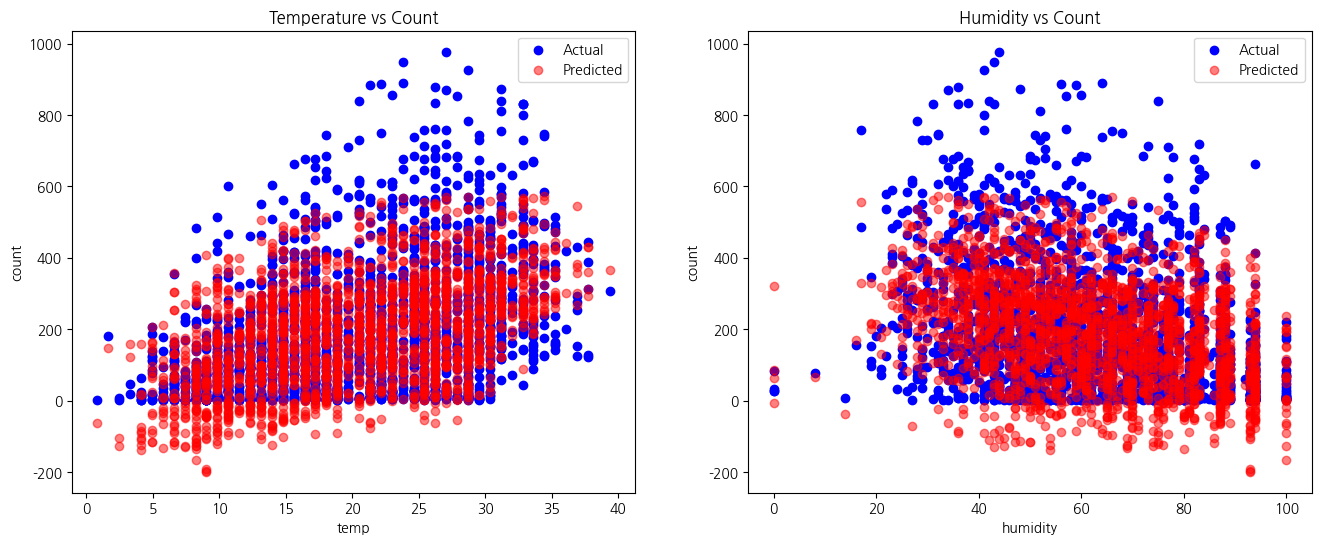

In [37]:
# (7) x축은 temp 또는 humidity로, y축은 count로 예측 결과 시각화하기

# 그래프 2개 나란히. 왼쪽 기온, 오른쪽 습도
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# 기온(temp) 별 대여량. 파랑 실제, 빨강 예측
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)  # alpha 투명도
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# 습도(humidity) 별 대여량
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

## (추가 실험) 정답(count) 로그변환으로 더 낮춰보기

원핫인코딩으로 RMSE 141 -> 100 까지 내렸다.
더 낮출 수 있을까? 이번엔 정답인 count(대여량) 자체의 분포를 의심해본다.

- 가설 : count 가 한쪽으로 쏠려있으면(작은값 많고 큰값 드뭄) 선형회귀가 큰값에 끌려다녀 불리하다.
- 실험 : count 에 로그를 씌워 분포를 펴준 뒤 다시 학습해서 RMSE 가 줄어드는지 본다.


    
  로그변환 정리

  1. 로그(log) 가 뭐냐
     - "몇 번 곱했나(규모)" 를 알려주는거. 거듭제곱의 반대.
     - 10=10^1 -> log 1, 100=10^2 -> log 2, 1000=10^3 -> log 3
     - 값이 x10 될때마다 로그는 +1. (코드의 np.log 는 기준이 e≈2.718 인 자연로그, 원리는 같음)

  2. 핵심 효과 : 큰 값은 확 줄이고, 작은 값은 덜 줄임
     - 원래값:  1,  10,  100,  1000   (간격 들쭉날쭉)
     - 로그후:  0, 2.3,  4.6,  6.9    (간격 고르게 압축됨)
     - 그래서 한쪽으로 쏠린 분포가 고르게 펴짐.

  3. 자전거 데이터에 왜 좋았나
     - count 는 작은값 잔뜩 + 큰값 가끔 = 오른쪽으로 쏠림(skew)
     - 로그 씌우면 분포가 펴져서, 선형회귀가 큰값에 안 끌려다니고 더 잘맞춤 (RMSE 100->95)

  4. log1p / expm1
     - log1p(x) = log(1+x) : 1 더하고 로그. count 가 0 일때 log(0) 에러 방지하려고 +1.
     - expm1(x) = e^x - 1  : log1p 의 역함수 (되돌리기)
     - 흐름 : 정답 --log1p--> 로그값으로 학습 --예측--> 로그값 예측 --expm1--> 원래 대여량 복원
     - 예측이 "로그 세계"로 나오니까, expm1 로 원래 단위(대여량)로 되돌려야 RMSE 계산이 맞음.

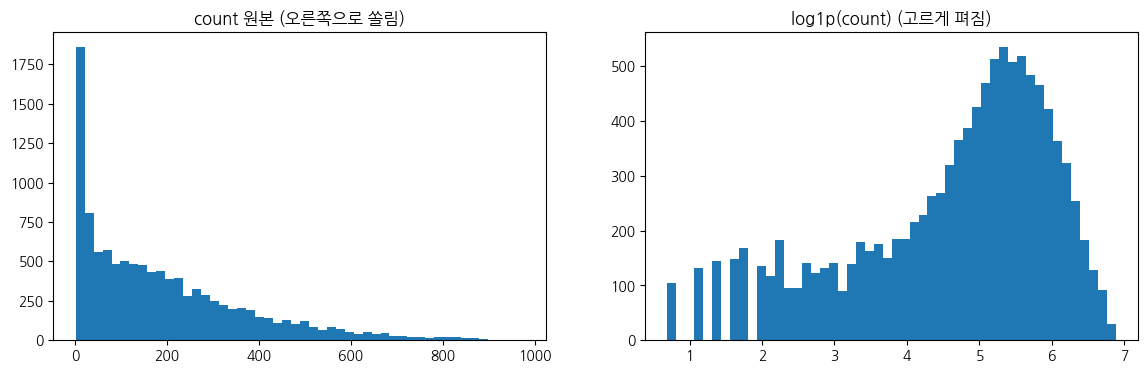

In [ ]:
# (실험1) 정답 count 의 분포를 눈으로 확인하기

import numpy as np
import matplotlib.pyplot as plt

# 폰트 설정
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# 왼쪽 : count 원본 분포
axs[0].hist(train['count'], bins=50)
axs[0].set_title('count 원본 (오른쪽으로 쏠림)')

# 오른쪽 : 로그 씌운 count 분포
# log1p = log(1+x). +1 해주는 이유는 count 가 0 일때도 안전하게(로그0 에러 방지) 계산하려고.
axs[1].hist(np.log1p(train['count']), bins=50)
axs[1].set_title('log1p(count) (고르게 펴짐)')
  
plt.show()
# 왼쪽: 작은값 엄청 많고 큰값 드뭄 (skew) -> 선형회귀가 큰값에 끌려다님
# 오른쪽: 로그 씌우니 분포가 좌우 고르게 펴짐 -> 학습에 유리할듯

In [39]:
# (실험2) 정답을 로그변환해서 다시 학습/평가

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# X_train, X_test, y_train, y_test 는 위 (4)번에서 만든 원핫 데이터 그대로 사용

# 정답을 log1p 로 변환해서 학습 (정답만 로그로 바꿈, 입력 X는 그대로)
model_log = LinearRegression()
model_log.fit(X_train, np.log1p(y_train))

# 예측값은 '로그 공간'으로 나오니까 expm1 로 원래 단위(대여량)로 되돌려야 함
# expm1 = log1p 의 역함수 (exp(x)-1)
y_pred_log = np.expm1(model_log.predict(X_test))
y_pred_log = np.clip(y_pred_log, 0, None)  # 혹시 음수 예측 나오면 0으로 (대여량은 음수가 없으니까)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print("원핫만 RMSE      :", 100.36)       # (6)번 결과
print("원핫+로그변환 RMSE:", rmse_log)     # 약 95 -> 더 좋아짐!

원핫만 RMSE      : 100.36
원핫+로그변환 RMSE: 94.93943443757506


### 실험 결론

| 방법 | RMSE |
|-----|------|
| 처음 (baseline) | 약 141 |
| 원핫인코딩 | 약 100 |
| 원핫 + 정답 로그변환 | 약 95 |

- count 가 한쪽으로 쏠린(skewed) 분포라서, 로그함수 처리로 쏠림 현상을 쏠리지 않게 펴주니 선형회귀가 더 잘 맞췄다.
- 핵심 교훈
  1. 범주형(hour 등)은 원핫인코딩 -> 직선 한계를 벗어남
  2. 쏠린 정답은 로그변환 -> 분포를 펴서 학습 안정화
- 둘 다 "데이터를 모델이 학습하기 좋은 형태로 바꿔주는" 역할이다.

## 학습 후기

처음엔 LMS 코드를 그냥 이 노트북에 옮겨놓기만 한 상태였다. AI, 통계, 머신러닝이 다 처음이라
코드가 무슨 말인지, 통계 이론이 뭔지 하나도 머리에 안 들어왔다. 그래서 셀 하나씩
뜯어보면서 주석이랑 메모로 직접 정리해가며 공부했다.

배운거 정리
- 지도학습 / 회귀 : 문제(X)랑 정답(y) 같이 주고 관계 배우는거. 숫자 예측이면 회귀.
- 선형회귀 : 예측 = w*x + b. 결국 정답 잘맞추는 W, b 를 찾는 과정.
- 행렬/행렬곱 : 표가 곧 행렬. 행렬곱은 "짝끼리 곱해서 더하기". 전치(.T)는 특성별로 더하려고 뒤집는거.
- 손실함수(MSE) / 기울기 / 경사하강법 : 손실 줄이는 방향(기울기 반대)으로 W,b 를 조금씩 갱신.
- 학습률 : 한걸음 크기. 너무 작으면 안내려가고 너무 크면 발산. (하이퍼파라미터)
- 편향(b) : 입력과 무관하게 늘 더해지는 값. 선을 위아래로 옮겨줌.
- 원핫인코딩 : 범주형(hour 등)을 0/1 칸으로 쪼개서 직선 한계를 벗어남.
- 로그변환 : 쏠린(skewed) 정답을 펴줘서 학습 안정화.
- 정답 누설 : casual+registered=count 처럼 정답 만드는 재료는 입력에 넣으면 반칙(컨닝).

결과
- 프로젝트1 (직접 구현) : 학습률/반복 조정해서 test MSE 5168 -> 2881 (목표 3000 이하 달성)
- 프로젝트2 (sklearn) : 원핫인코딩으로 RMSE 141 -> 100, 로그변환까지 하니 95 까지 내려감.

삽질 기록 (환경)
- 맥에서 SMB로 리눅스 파일 열어 쓰다보니 커널/라이브러리 문제 겪음.
- aiffel 콘다 환경 새로 만들고, VS Code Remote-SSH 로 리눅스에 직접 붙어서 해결.
- 그래프 한글 깨지는건 나눔고딕 폰트 등록해서 해결.

느낀점
- 코드를 그냥 돌리는거랑, 한줄씩 왜 그런지 이해하는건 완전 다른 일이었다.
- 특히 프로젝트1에서 손으로 만든게 프로젝트2의 LinearRegression 이랑 같은거란걸 알았을때
  머신러닝이 무슨 마법이 아니라 결국 W,b 찾기구나 하고 감이 잡혔다.
- 원핫, 로그변환으로 데이터 형태를 학습에 편리하도록 보정하니 점수가 실제로 내려가는걸 보면서 재밌었다.